In [2]:
import dask
dask.config.set({'dataframe.query-planning': False})

In [3]:
import h5py
import seaborn as sns
from gprofiler import GProfiler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import beta as beta_dist
import numpy as np

In [4]:
import scarf
scarf .__version__

'0.32.3'

In [ ]:
## repeat this for all 7 h5ad files
reader = scarf.H5adReader(
    h5ad_fn="CaB.h5ad",
    cell_ids_key="CellID",          
    feature_ids_key="_index",        
    feature_name_key="feature_name", 
    matrix_key="X",                     
)

writer = scarf.H5adToZarr(
    reader,
    zarr_loc='CaB.zarr',
    chunk_size=(2000,1000)
)
writer.dump()

## Load SN_VTA seperately, AND VP_MOUSE

INFO: No value provided for assay names. Will use default value: 'RNA'


Reading attributes from group obs:   0%|                                                                      …

Reading attributes from group obsm:   0%|                                                                     …

Reading attributes from group var:   0%|                                                                      …

  0%|                                                                                                         …

In [59]:
ds_GPe = scarf.DataStore(
    'GPe.zarr', 
    nthreads=4
)
ds_GPi = scarf.DataStore(
    'GPi.zarr', 
    nthreads=4
)
ds_CaB = scarf.DataStore(
    'CaB.zarr', 
    nthreads=4
)

ds_NAC = scarf.DataStore(
    'NAC.zarr', 
    nthreads=4
)

ds_PU = scarf.DataStore(
    'PU.zarr', 
    nthreads=4
)

ds_SN = scarf.DataStore(
    'SN.zarr', 
    nthreads=4
)

ds_STH = scarf.DataStore(
    'STH.zarr', 
    nthreads=4
)


In [61]:
scarf.AssayMerge(
    zarr_path = '/Users/saatvikviniak/Desktop/Lab work/sc-RNA atlas/merged.zarr',
    assays = [ds_GPe.RNA, ds_GPi.RNA, ds_CaB.RNA, ds_NAC.RNA, ds_PU.RNA, ds_SN.RNA, ds_STH.RNA],
    names = ['GPe', 'GPi', 'CaB', 'NAC', 'PU', 'SN', 'STH',],
    merge_assay_name='RNA',
    overwrite=True
).dump()

Writing data from assay 1/7 to merged file:   0%|                                                             …

Writing data from assay 2/7 to merged file:   0%|                                                             …

Writing data from assay 3/7 to merged file:   0%|                                                             …

Writing data from assay 4/7 to merged file:   0%|                                                             …

Writing data from assay 5/7 to merged file:   0%|                                                             …

Writing data from assay 6/7 to merged file:   0%|                                                             …

Writing data from assay 7/7 to merged file:   0%|                                                             …

# QC + Preprocessing here

## When running qc, if need to reset the dataset, to modify settings like min_features_per_cell, run the following commented commands, then load the dataset again
ds.cells.insert('I', np.ones(ds.cells.N, dtype=bool), overwrite=True, force=True)

ds.RNA.feats.insert('I', np.ones(ds.RNA.feats.N, dtype=bool), overwrite=True, force=True)

In [5]:
ds = scarf.DataStore(
    'merged.zarr',
    nthreads=6,
    min_features_per_cell=800,  # filtrs out cells expressing 800 or less genes
    min_cells_per_feature=100   # filters out genes expressed in less than 100 cells
)

GroupNotFoundError: group not found at path ''

In [66]:
## Keep track of cells from different samples by adding a column known as sample id, easily associate what cell is from dataset
ds.cells.insert(
    column_name='sample_id',
    values=[x.split('__')[0] for x in ds.cells.fetch_all('ids')],
    overwrite=True
)

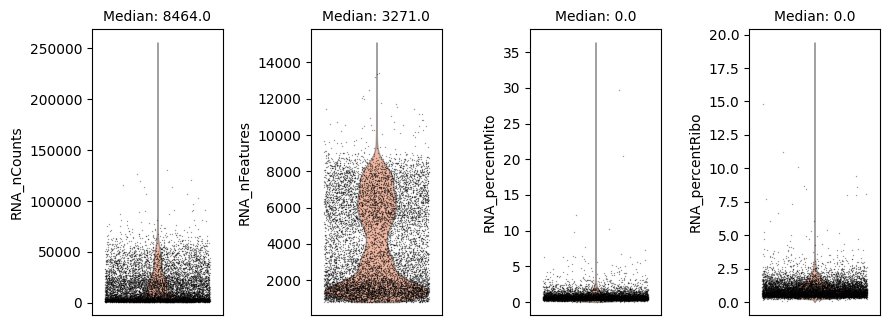

In [67]:
ds.plot_cells_dists(cell_key='I', color='coral')

In [ ]:
## 255905 cells pre-qc
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo'],
    highs=[60000, 9000, 3.0, 2.4],  
    lows=[1000,  500,  0.0, 0.0]
)

## 242636 cells post QC

INFO: 5311 cells flagged for filtering out using attribute RNA_nCounts
INFO: 1953 cells flagged for filtering out using attribute RNA_nFeatures
INFO: 2743 cells flagged for filtering out using attribute RNA_percentMito
INFO: 7254 cells flagged for filtering out using attribute RNA_percentRibo


In [70]:
ds

DataStore has 242634 (261691) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'orig_RNA_nCounts', 'orig_RNA_nFeatures', 'orig_RNA_percentMito', 
            'orig_RNA_percentRibo', 'orig_X_UMAP1', 'orig_X_UMAP2', 'orig_X_tSNE1', 'orig_X_tSNE2', 
            'orig_cell_cycle_score', 'orig_fraction_mitochondrial', 'orig_fraction_unspliced', 'orig_is_primary_data', 'orig_observation_joinid', 
            'orig_total_UMIs', 'orig_total_genes', 'sample_id'
   RNA assay has 31864 (58232) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

In [71]:
ds.RNA.feats.head()

,I,ids,names,dropOuts,nCells
0,True,ENSG00000271098,IMMP1LP3,261281,410
1,True,ENSG00000251026,NIHCOLE,258979,2712
2,True,ENSG00000129451,KLK10,260495,1196
3,True,ENSG00000163568,AIM2,256514,5177
4,True,ENSG00000253327,RAD21-AS1,260780,911


INFO: Calculating summary statistics


(RNA) Computing nCells:   0%|                                                                                 …

(RNA) Computing normed_tot:   0%|                                                                             …

(RNA) Computing sigmas:   0%|                                                                                 …

INFO: Calculating HVGs
INFO: 3990 genes marked as HVGs


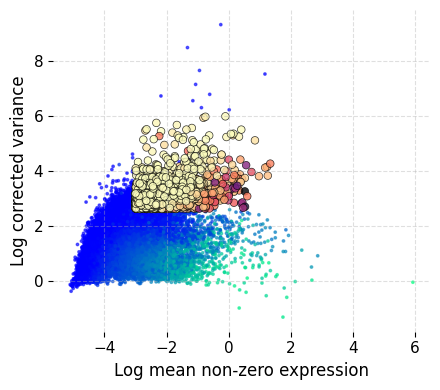

In [72]:
ds.mark_hvgs(
    min_cells=100, # Gene should have non-zero expression values in at least 100 cells
    top_n=4000,
    min_mean=-3, # come back and fully refine the following 3 parameters
    max_mean=2,
    max_var=6
)

### Graph Creation ~ Performing batch correction using harmony here

Normalizing with feature subset:   0%|                                                                        …

Writing data to normed__I__hvgs/data:   0%|                                                                   …

Calculating mean of norm. data:   0%|                                                                         …

Calculating std. dev. of norm. data:   0%|                                                                    …

INFO: Cluster number reduced to batch size of 1000


...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.13/lib/p

Estimating seed partitions:   0%|                                                                             …

Identifying neighbors:   0%|                                                                                  …

Smoothening KNN distances:   0%|                                                                              …

INFO: ANN recall: 99.73%


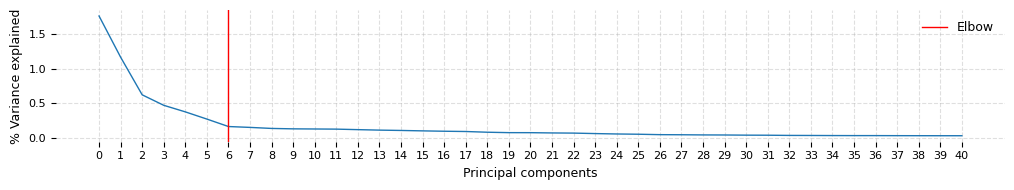

In [73]:
ds.make_graph(
    feat_key='hvgs',
    k=30, # starting wit a total of 35 nearest neighbors
    dims=40,
    n_centroids=3000, # For centroids, calculating roughly using ~ Total cell count / 100. Have a value of 1+ (>1) for every 100 cells
    show_elbow_plot = True,
    harmonize = True,
    batch_columns = ['sample_id'],
)

In [ ]:
ds.run_umap(
    n_epochs=300, # Starting with default
    spread=5, #For purely visualization purposes
    min_dist=1, #For purely visualization purposes
    random_seed=2009)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3

Training UMAP:   0%|                                                                                          …

	completed  0  /  300 epochs


In [76]:
ds.cells.head()

,I,ids,names,RNA_UMAP1,RNA_UMAP2,RNA_nCounts,RNA_nFeatures,RNA_percentMito,RNA_percentRibo,orig_RNA_nCounts,...,orig_X_tSNE1,orig_X_tSNE2,orig_cell_cycle_score,orig_fraction_mitochondrial,orig_fraction_unspliced,orig_is_primary_data,orig_observation_joinid,orig_total_UMIs,orig_total_genes,sample_id
0,True,GPi__10X357_1:GCATTAGGTTGGGTAG,10X357_1:GCATTAGGTTGGGTAG,42.044376,3.454543,2408.0,1324.0,0.581395,0.581395,2408.0,...,1.189798,-32.696562,0.001650,0.001650,0.638201,True,v3B6Zv6z_d,2424.0,1335.0,GPi
1,True,GPi__10X385_3:TCGGGCAGTCAGGCAA,10X385_3:TCGGGCAGTCAGGCAA,48.766453,1.836090,2373.0,1323.0,1.348504,0.842815,2373.0,...,1.087873,-36.468209,0.000419,0.000839,0.571728,True,xTIYJ0;=HN,2384.0,1332.0,GPi
2,True,GPi__10X389_7:CATGGATTCAACTGAC,10X389_7:CATGGATTCAACTGAC,42.961918,23.136290,2123.0,1317.0,0.659444,0.565238,2123.0,...,32.337446,-27.800528,0.000468,0.000000,0.644528,True,1Z4_+ehJ<g,2138.0,1329.0,GPi
3,True,GPi__10X385_3:AGCTCAAGTCCAATCA,10X385_3:AGCTCAAGTCCAATCA,47.092979,5.768233,3080.0,1512.0,0.584416,0.681818,3080.0,...,10.872583,-32.420473,0.000323,0.001613,0.637625,True,niqw9wf)Xp,3099.0,1524.0,GPi
4,True,GPi__10X389_7:ATGGGTTAGCTGTGCC,10X389_7:ATGGGTTAGCTGTGCC,41.809128,21.712521,1257.0,872.0,0.954654,0.954654,1257.0,...,33.715825,-32.900576,0.000000,0.001585,0.578447,True,e@s7)@#6s%,1262.0,877.0,GPi


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


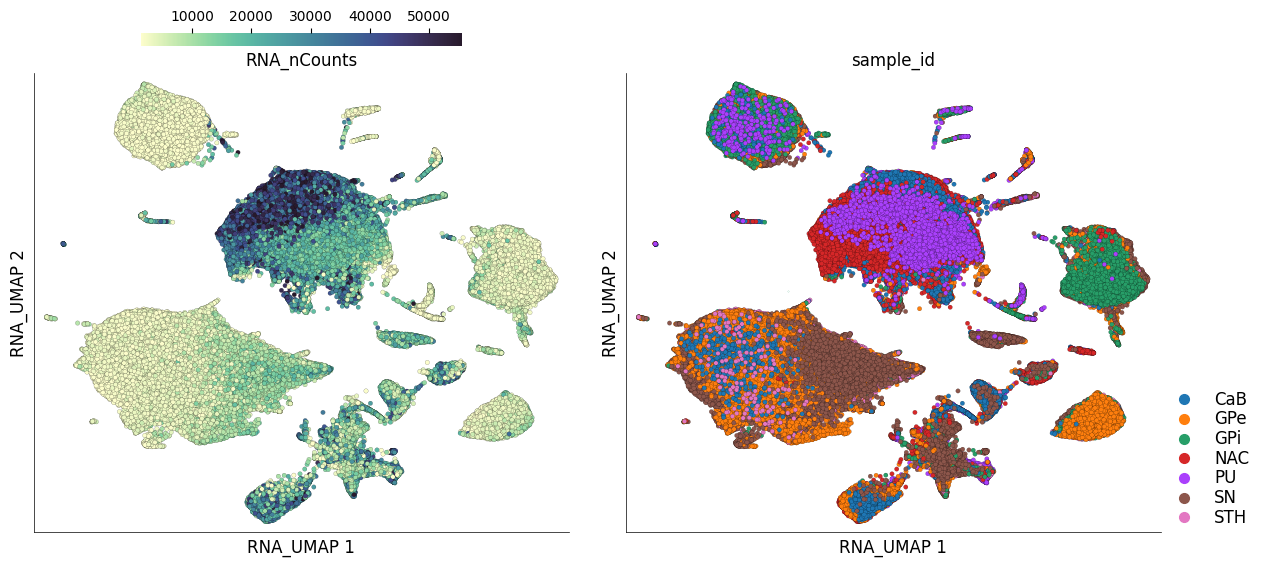

In [79]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by=['RNA_nCounts','sample_id'],
    legend_ondata=False
)

In [80]:
ds.run_leiden_clustering(resolution=.9) 

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


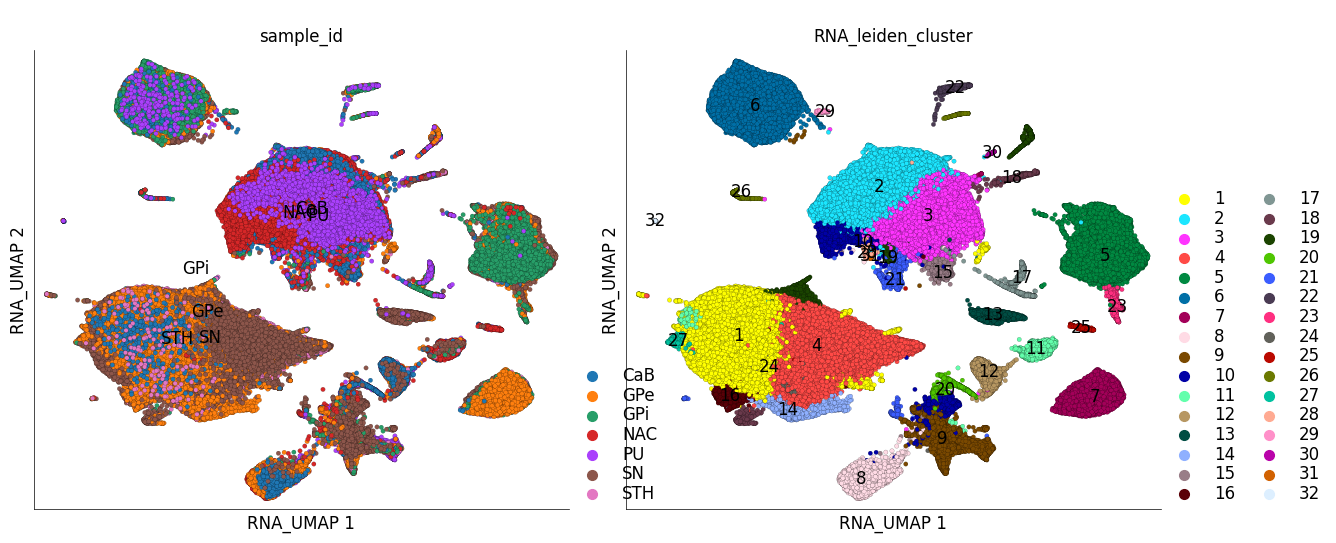

In [81]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by=['sample_id','RNA_leiden_cluster'],
)
#savename=None, save_dpi=300